Try different sigma dependencies \& determine the best one based off of $\Delta \chi^2$

In [1]:
from escripts import eMCMC
from escripts import eplots
import importlib
from escripts import edata
import time

SyntaxError: invalid syntax. Perhaps you forgot a comma? (eplots.py, line 115)

In [ ]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Constant $\sigma$

In [201]:
param_const = eMCMC.build_param_data({'dsigdlogM': {'fit':False}, 'dsigdz': {'fit':False}})

In [208]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [209]:
UVLF_const = eMCMC.UVLF(file_names, data_labels, param_const)

In [210]:
ICs_const = UVLF_const.generate_ICs()

In [211]:
# Run MCMC
Nsteps=4000
_ = UVLF_const.sampler.run_mcmc(ICs_const, Nsteps) 

In [212]:
# Get flat sample from the MCMC
samples_const, best_fit_const, labels = UVLF_const.get_fit()

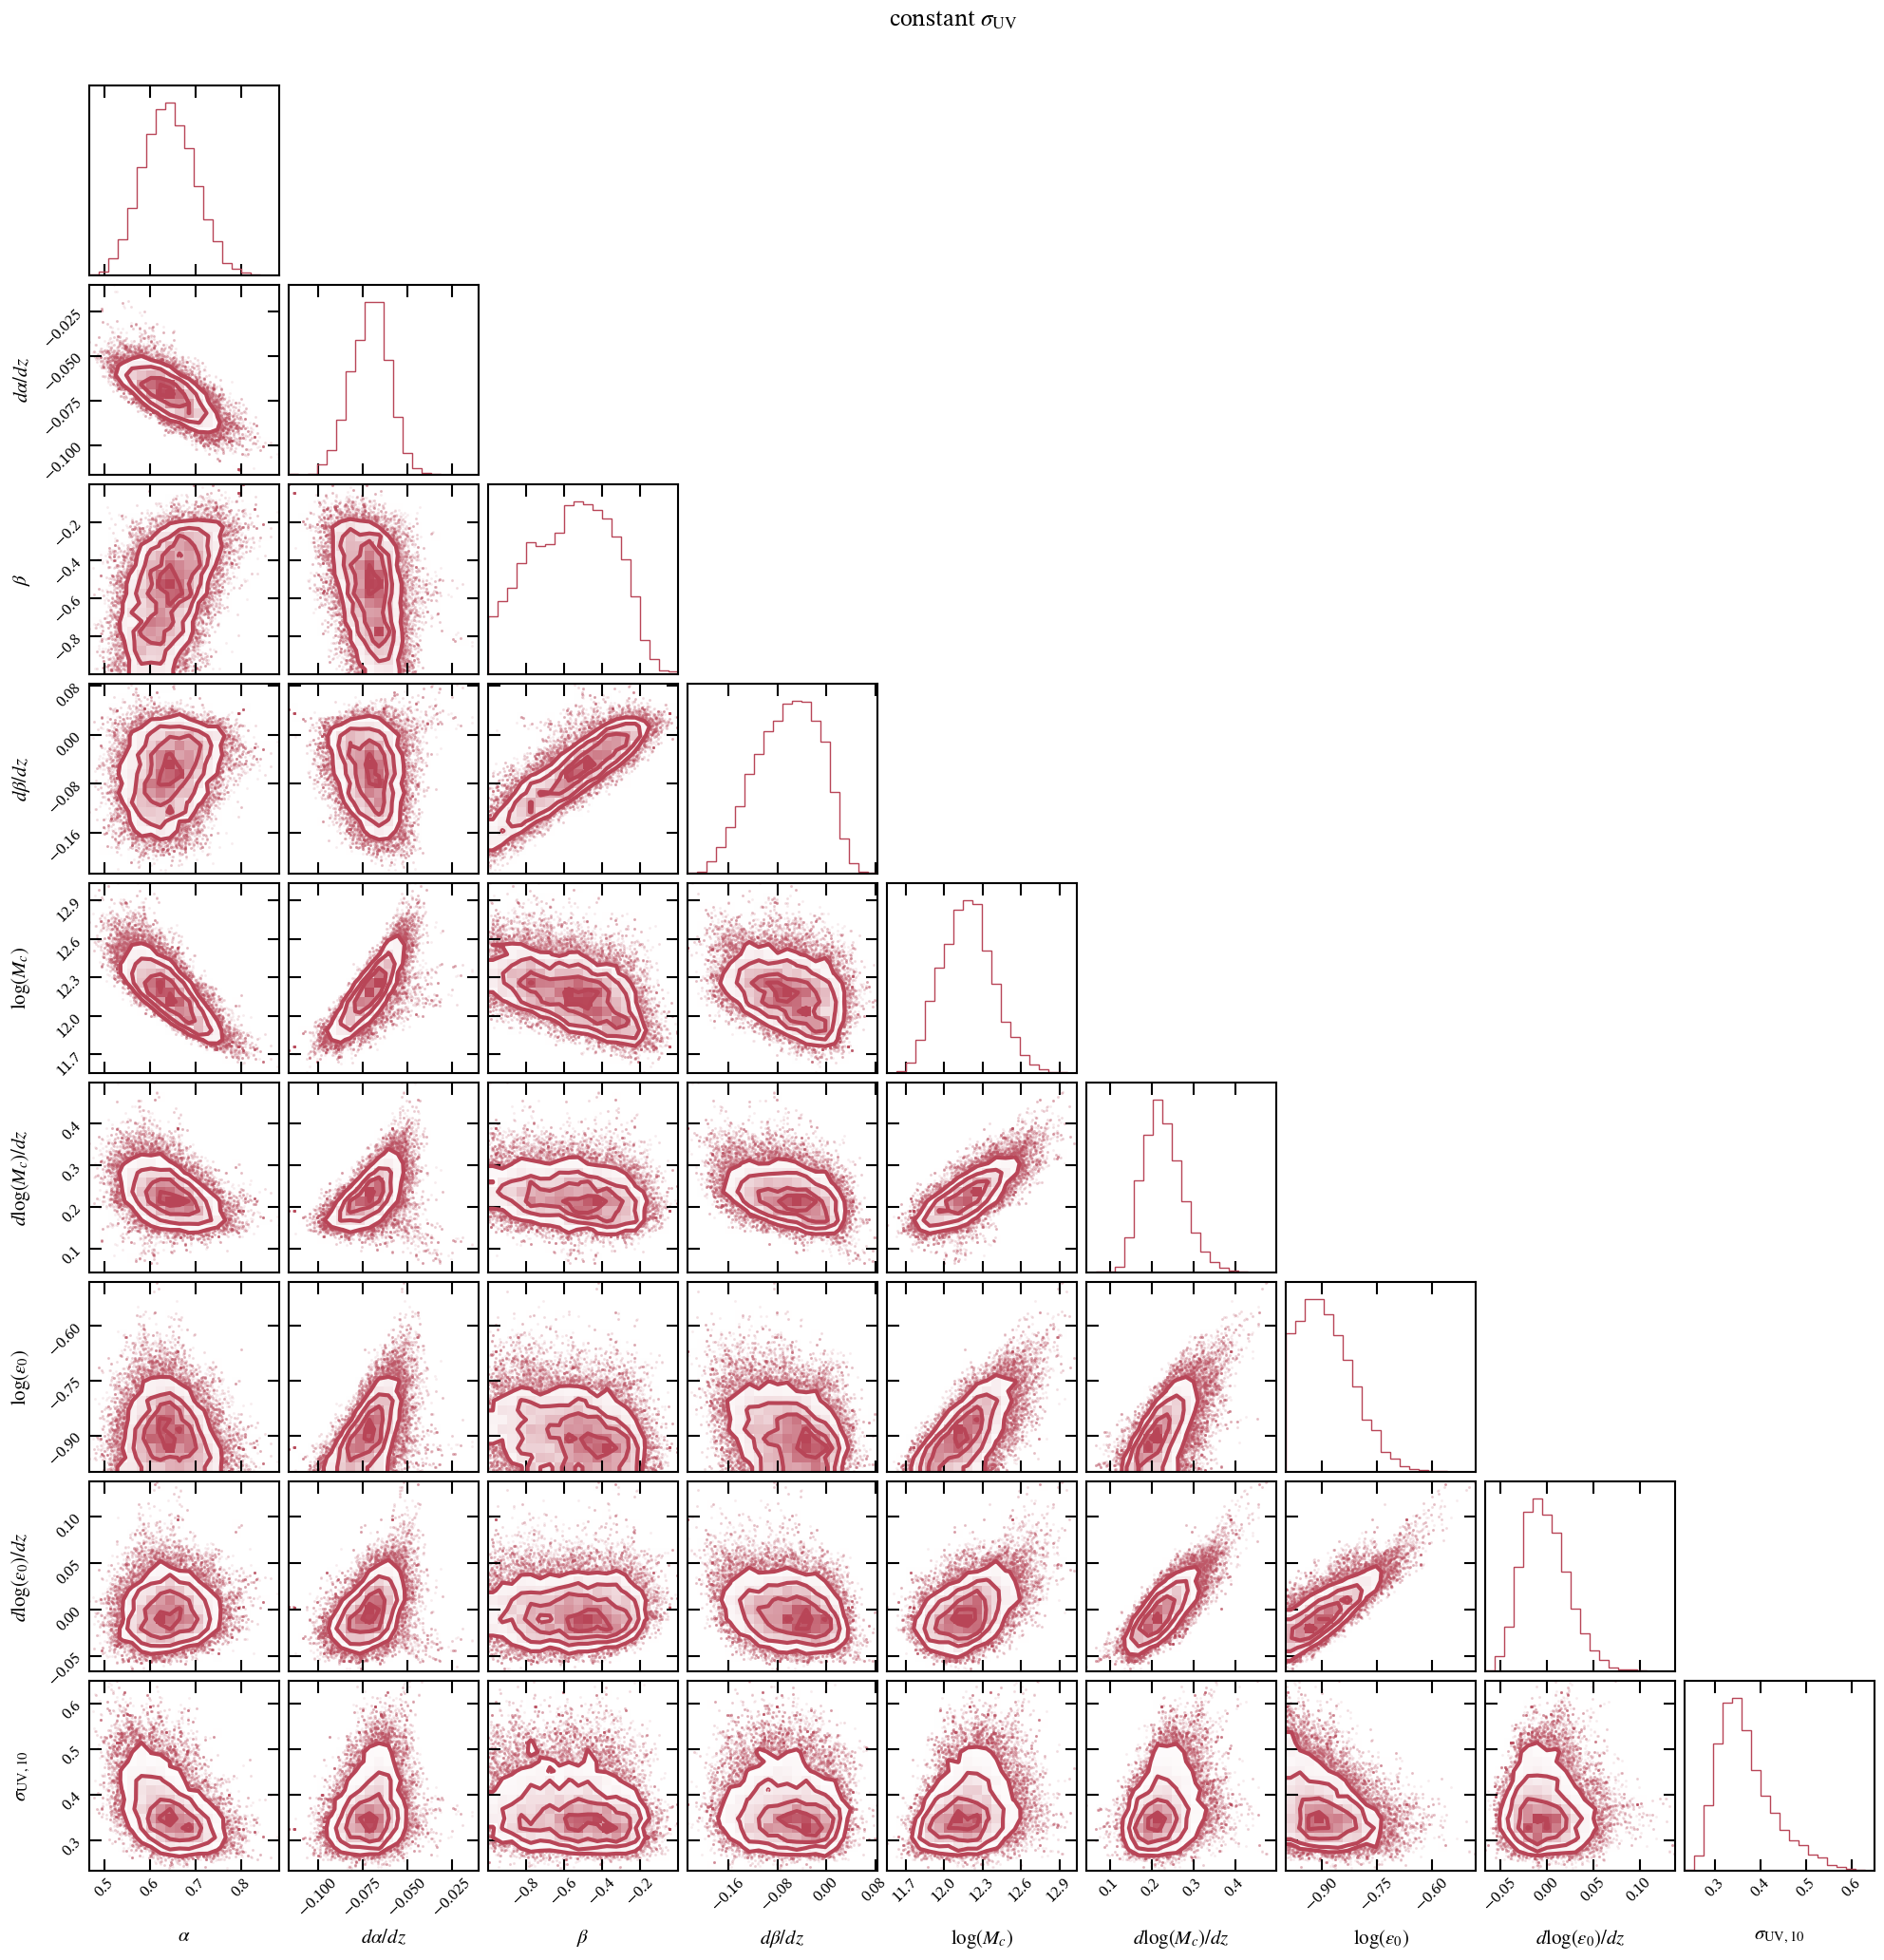

In [213]:
corner_const = Plotting.plot_corner(samples_const, UVLF_const, title = r'constant $\sigma_{\rm{UV}}$')

In [214]:
#corner_const.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/posterior_const_sig.png', bbox_inches='tight')

In [215]:
print(best_fit_const)

[0.67, -0.08, -0.5, -0.04, 12.06, 0.19, -0.91, -0.02, 0.31, 0, 0]


# $\sigma(M_h)$

In [216]:
param_M = eMCMC.build_param_data({'dsigdz': {'fit': False}})

In [217]:
UVLF_M = eMCMC.UVLF(file_names, data_labels, param_M)

In [218]:
ICs_M = UVLF_M.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [219]:
# Run MCMC
_ = UVLF_M.sampler.run_mcmc(ICs_M, Nsteps) 

In [220]:
samples_M, best_fit_M, _ = UVLF_M.get_fit()

In [221]:
print(best_fit_M)

[0.66, -0.04, -0.33, -0.03, 12.6, 0.3, -0.9, 0.02, 1.31, 0, -0.44]


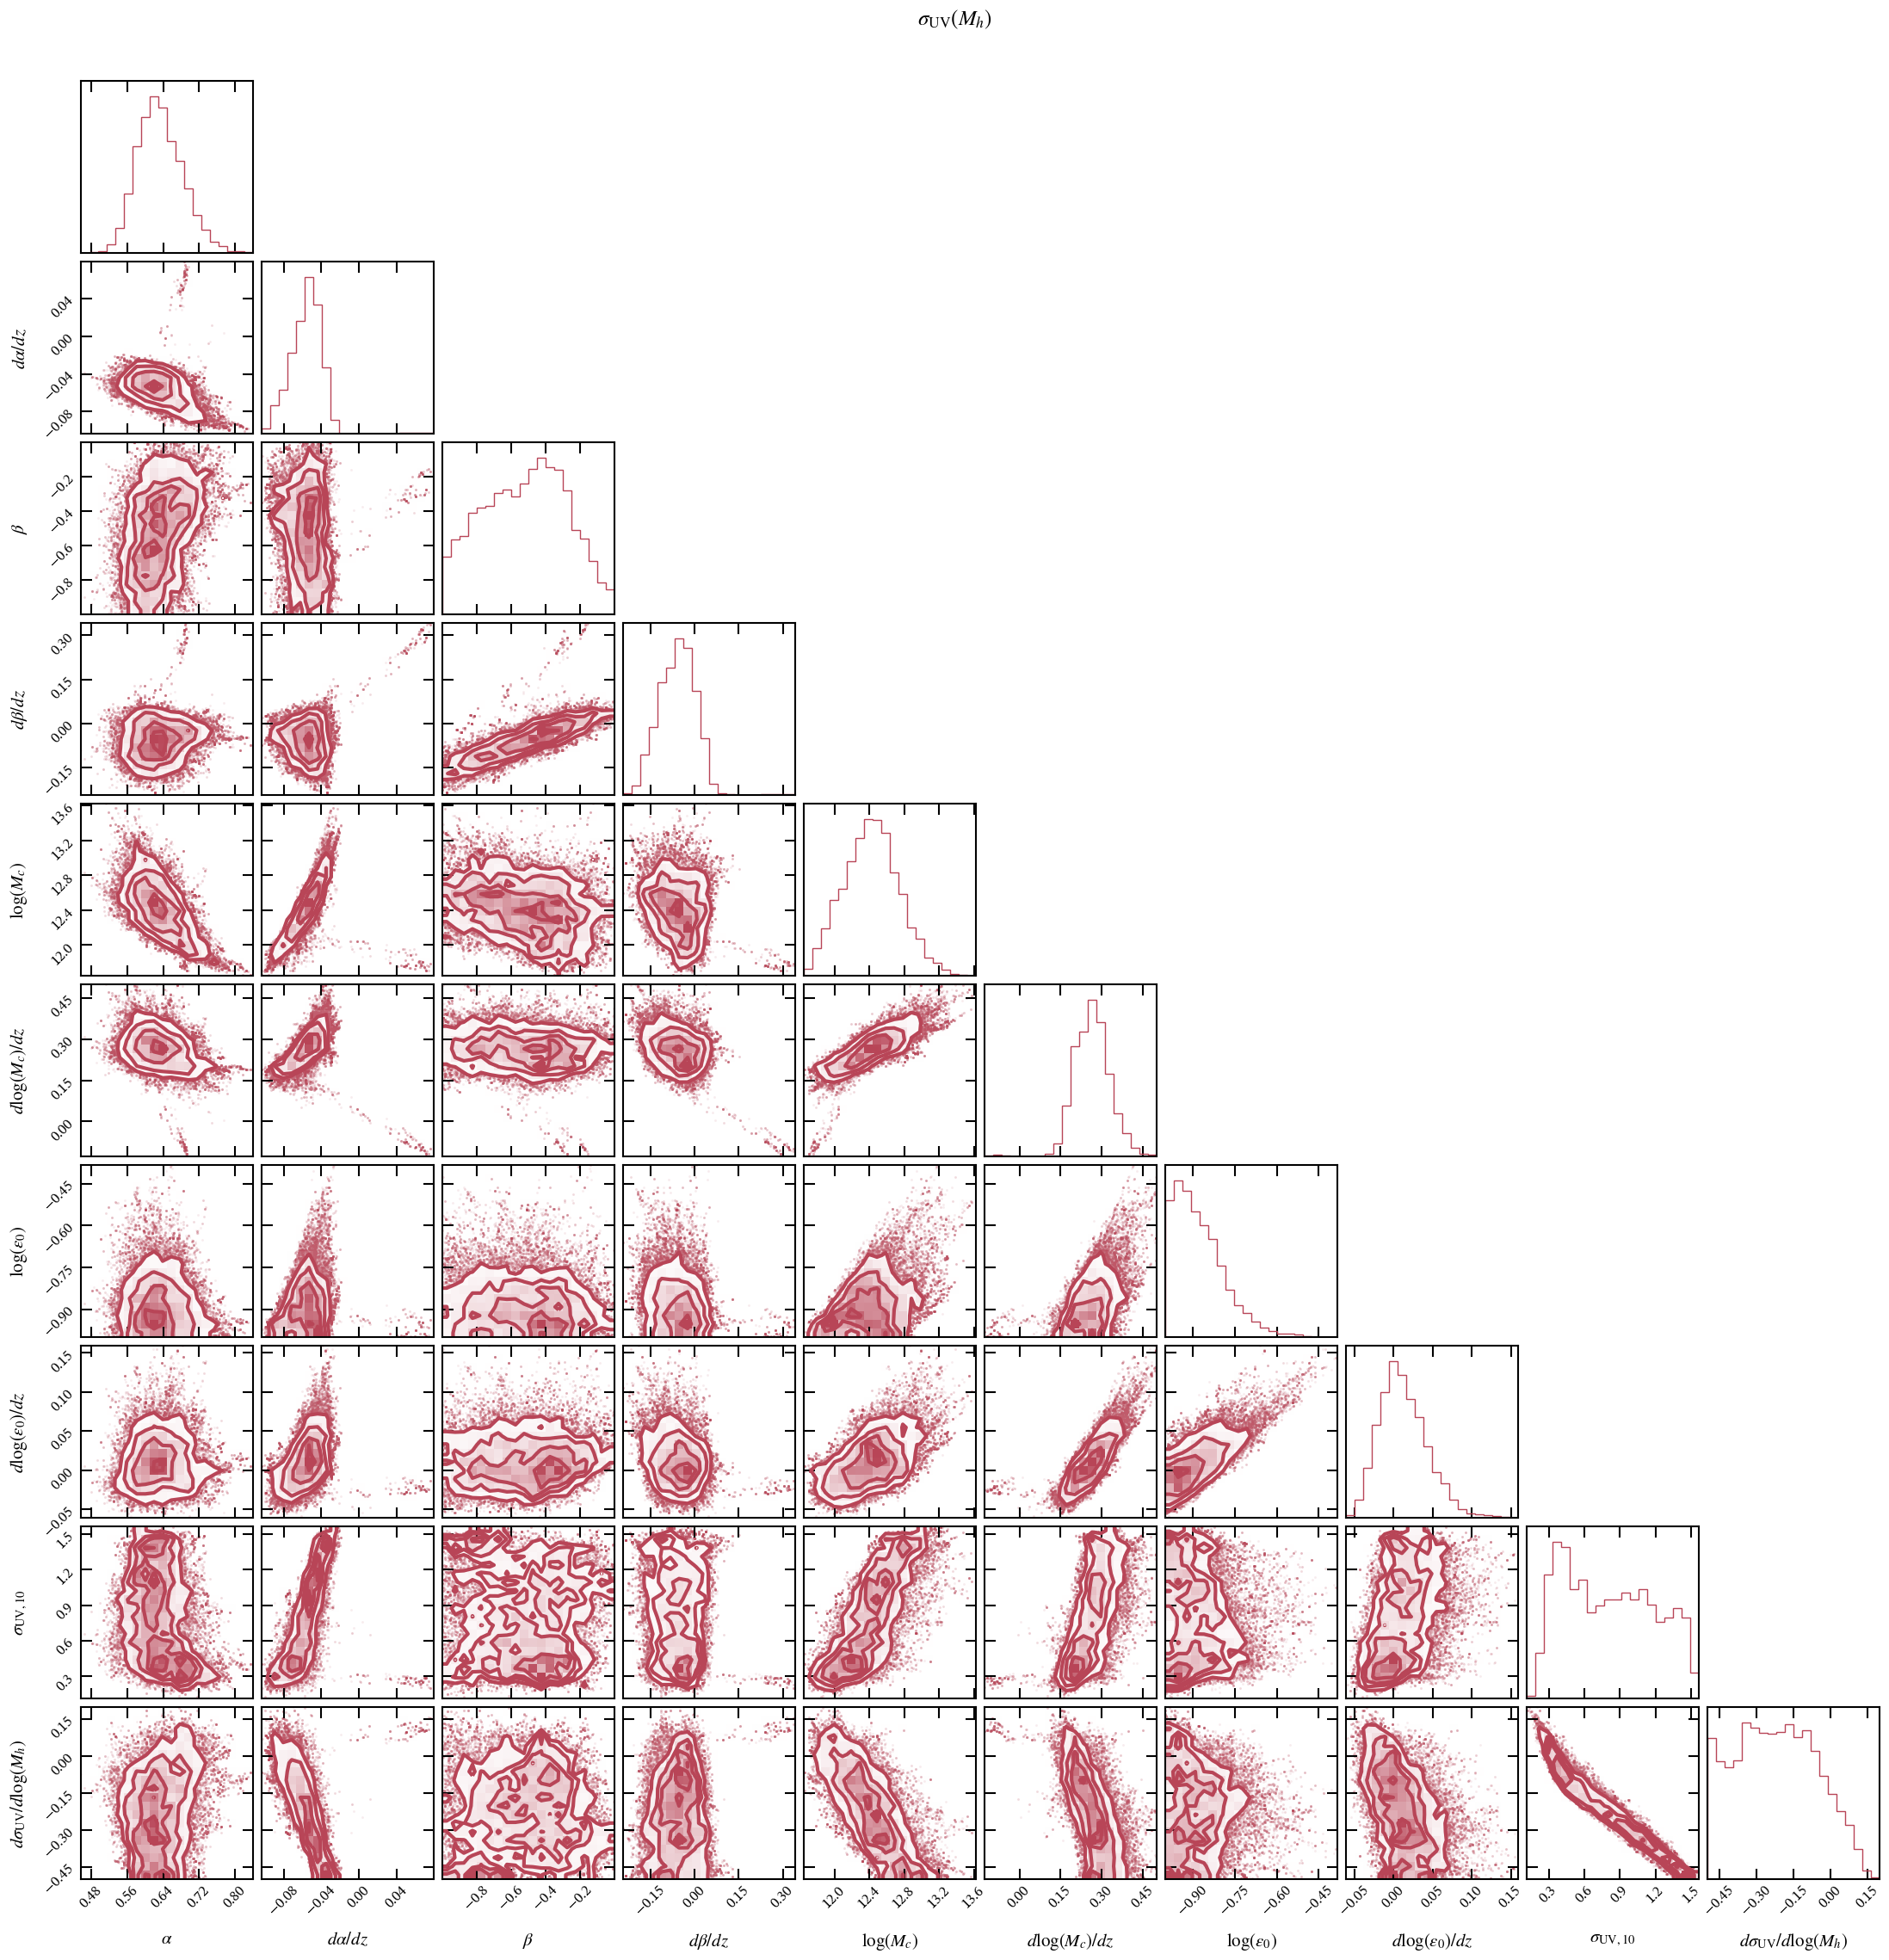

In [222]:
corner_M = Plotting.plot_corner(samples_M, UVLF_M, title = r'$\sigma_{\rm{UV}}(M_h)$')

In [223]:
#corner_M.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/weird_posterior_sig_m.png', bbox_inches='tight')

# $\sigma(z)$

In [224]:
params_z = eMCMC.build_param_data({'dsigdlogM': {'fit': False}})

In [225]:
UVLF_z = eMCMC.UVLF(file_names, data_labels, params_z)

In [226]:
ICs_z = UVLF_z.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [227]:
# Run MCMC
_ = UVLF_z.sampler.run_mcmc(ICs_z, Nsteps) 

In [228]:
samples_z, best_fit_z, _ = UVLF_z.get_fit()

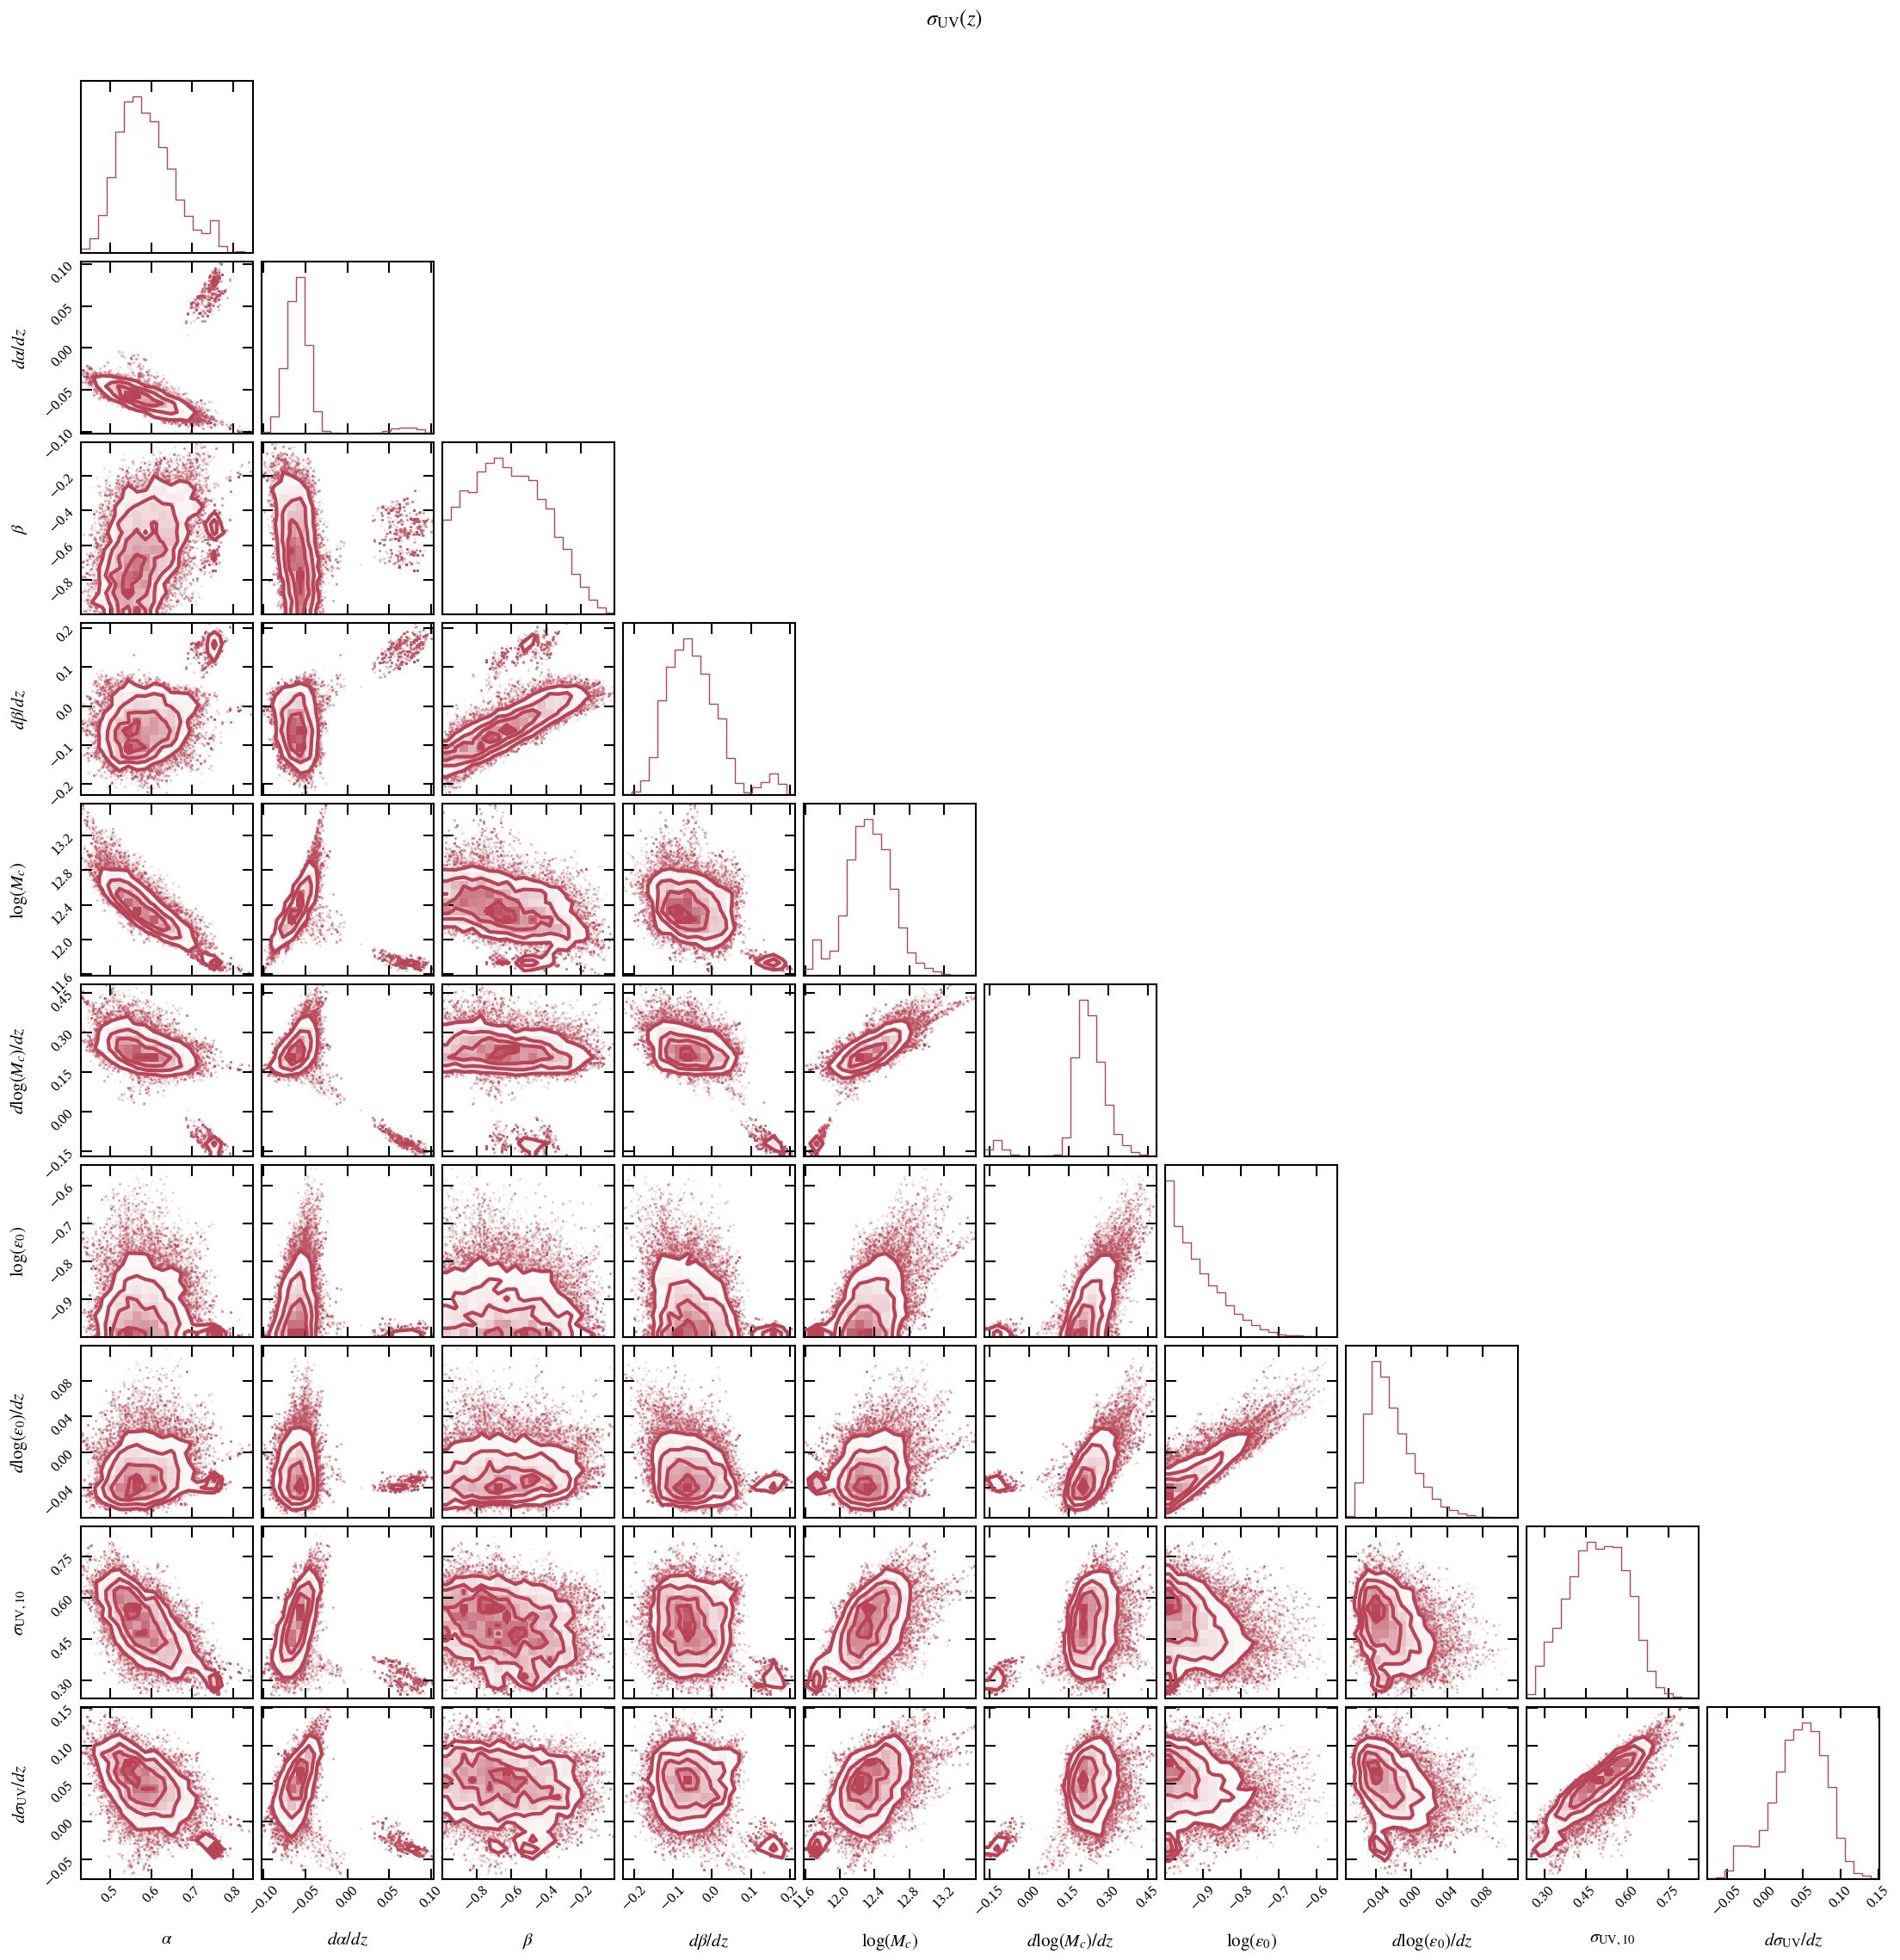

In [229]:
corner_z = Plotting.plot_corner(samples_z, UVLF_z, title = r'$\sigma_{\rm{UV}}(z)$')

In [230]:
#corner_z.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/posterior_sig_z.png', bbox_inches = 'tight')

In [231]:
print(best_fit_z)

[0.66, -0.07, -0.38, -0.01, 12.03, 0.17, -0.95, -0.03, 0.42, 0.04, 0]


# $\sigma(M_h, z)$

In [15]:
eMCMC.get_default_df()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [16]:
params_all = eMCMC.build_param_data({'loge': {'lower': -1.5}, 'dsigdz': {'upper': 1}})

In [17]:
UVLF_all = eMCMC.UVLF(sorted_data, params_all)

In [2]:
# Set up the backend
# Don't forget to clear it in case the file already exists
import emcee
nwalkers = 22
ndim = 11
filename = "tutorial.h5"
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

# Initialize the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, backend=backend)

NameError: name 'log_prob' is not defined

In [36]:
UVLF_all.run_MCMC(Nsteps=2000)

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70000/70000 [1:18:14<00:00, 14.91it/s]


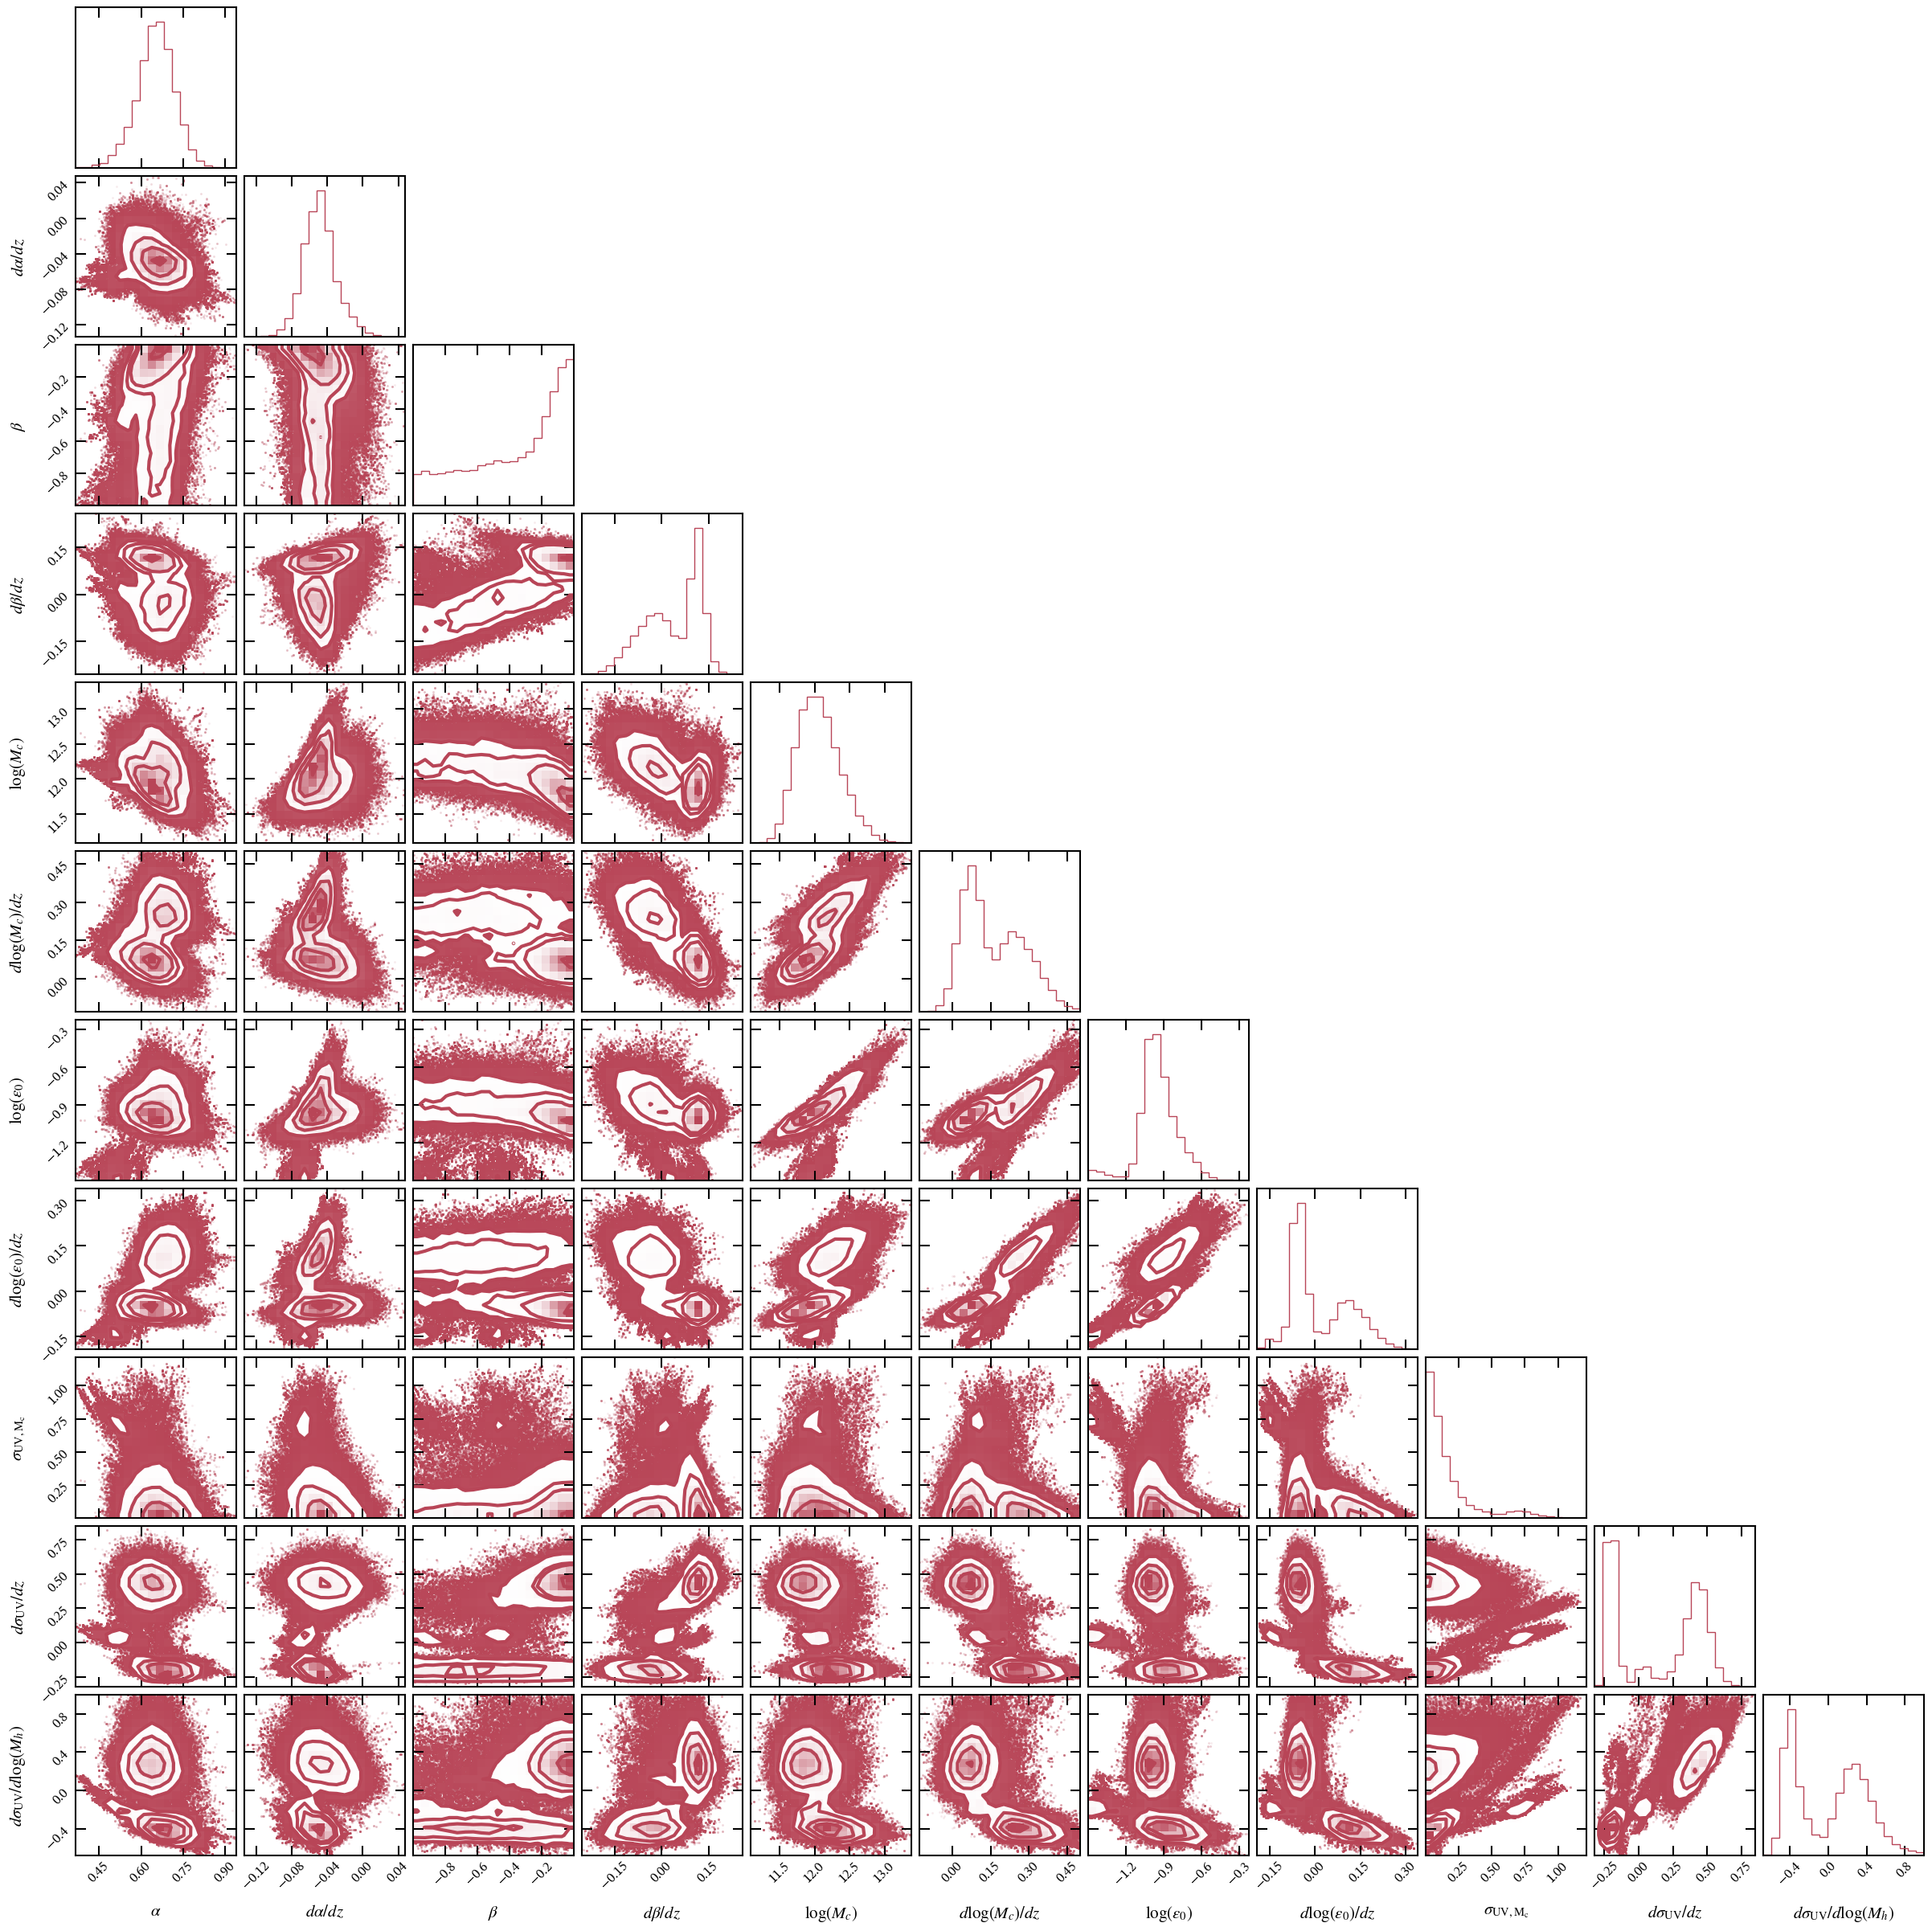

In [37]:
corner = eplots.make_corner(UVLF_all)

In [40]:
#corner.savefig('/Users/eb35267/Desktop/code/figures/corner_weird.png')

In [41]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all

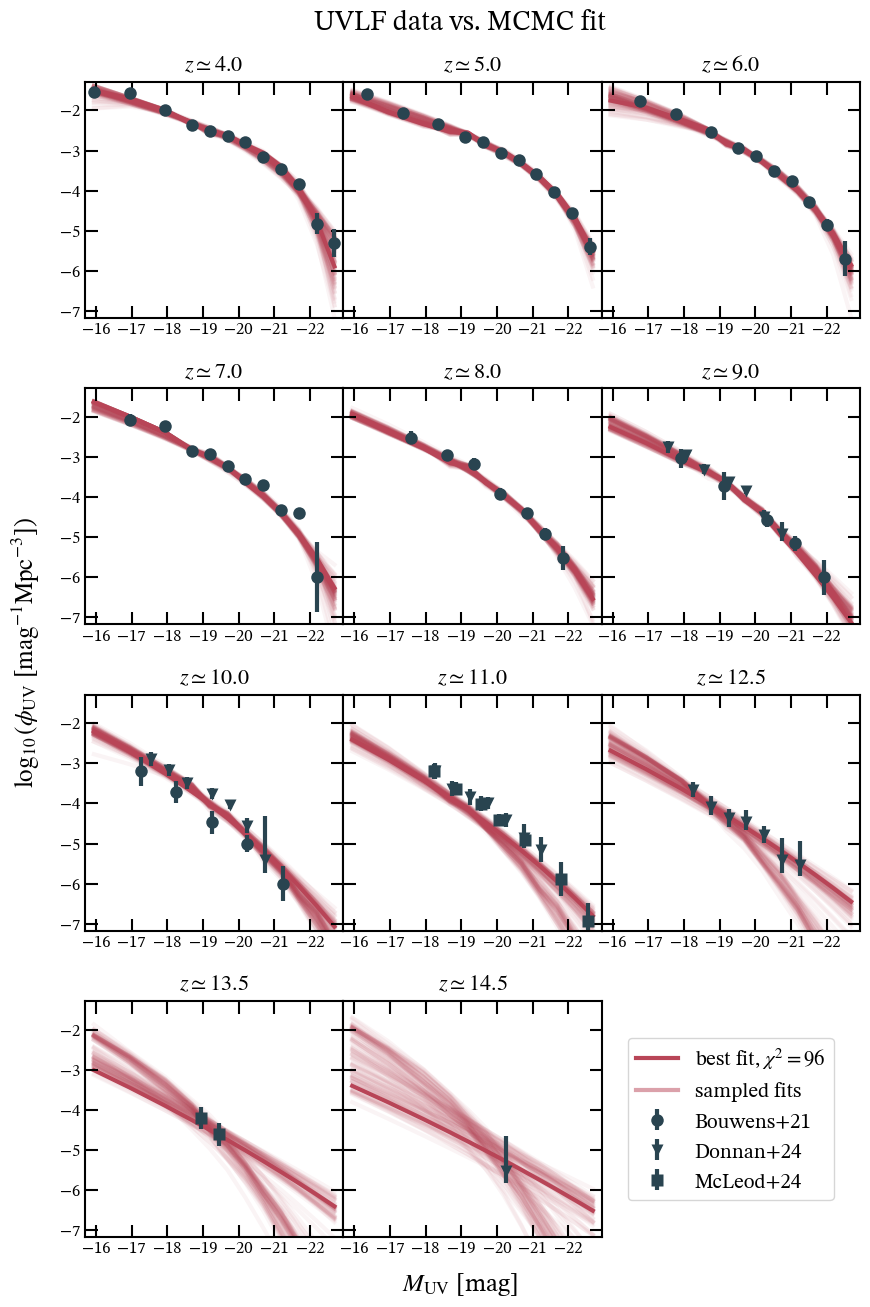

In [42]:
fit = eplots.evolving_UVLF_fit(UVLF_all)

In [43]:
fit.savefig('/Users/eb35267/Desktop/code/figures/fit_weird.png', bbox_inches='tight')

In [34]:
samples, bf, labels = UVLF_all.get_fit()

In [35]:
eMCMC.make_table([bf], labels, ['best fit'])

,best fit
$\alpha$,0.67
$d\alpha/dz$,-0.06
$\beta$,-0.01
$d\beta/dz$,0.12
$\log(M_c)$,11.67
$d\log(M_c)/dz$,0.05
$\log(\epsilon_0)$,-1.05
$d\log(\epsilon_0)/dz$,-0.07
"$\sigma_{\rm{UV}, M_c}$",0.03
$d\sigma_{\rm{UV}}/dz$,0.46


# Comparison

In [16]:
comparison = Plotting.compare_fits(file_names, data_labels, [best_fit_const, best_fit_M, best_fit_z, best_fit_all], 
        fit_labels = [r'constant $\sigma_{\rm{UV}}$', r'$\sigma_{\rm{UV}}(M_h)$', r'$\sigma_{\rm{UV}}(z)$', r'$\sigma_{\rm{UV}}(M_h, z)$'],
                                  title = 'Fit comparison')

NameError: name 'best_fit_const' is not defined

In [9]:
# phi_save = [UVLF_all.UVLF_wrapper(UVLF_all.data[i][0], UVLF_all.data[i][1], UVLF_all.data[0][2], UVLF_all.data[0][-1], best_fit_all) for i in 
#         np.arange(7, 11, 1)]

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


In [10]:
# redshifts = [np.full(len(UVLF_all.data[0][2]), UVLF_all.data[i][0]) for i in np.arange(7, 11, 1)]
# magnitudes = [UVLF_all.data[0][2] for i in np.arange(7, 11, 1)]
# dmag = [UVLF_all.data[0][-1] for i in np.arange(7, 11, 1)]
# plus_sig = [np.full(len(UVLF_all.data[0][2]), 0) for i in np.arange(7, 11, 1)]
# minus_sig = [np.full(len(UVLF_all.data[0][2]), 0) for i in np.arange(7, 11, 1)]

In [11]:
# eMCMC.save_data(redshifts, magnitudes, dmag, phi_save, plus_sig, minus_sig, 
#                 file_name = '/Users/eb35267/Desktop/code/home/data/z11-14.5_without_dust.txt')

In [241]:
#comparison.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/diff_sigma_func_just_HST.png', bbox_inches='tight')

In [242]:
#comparison.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/diff_sigma_func_compare.png', bbox_inches='tight')

In [243]:
table = eMCMC.make_table([best_fit_const, best_fit_M, best_fit_z, best_fit_all], labels, 
        fit_labels = [r'constant $\sigma_{\rm{UV}}$', r'$\sigma_{\rm{UV}}(M_h)$', r'$\sigma_{\rm{UV}}(z)$', r'$\sigma_{\rm{UV}}(M_h, z)$'])

In [244]:
table

,constant $\sigma_{\rm{UV}}$,$\sigma_{\rm{UV}}(M_h)$,$\sigma_{\rm{UV}}(z)$,"$\sigma_{\rm{UV}}(M_h, z)$"
$\alpha$,0.67,0.66,0.66,0.62
$d\alpha/dz$,-0.08,-0.04,-0.07,-0.04
$\beta$,-0.5,-0.33,-0.38,-0.58
$d\beta/dz$,-0.04,-0.03,-0.01,-0.08
$\log(M_c)$,12.06,12.6,12.03,12.63
$d\log(M_c)/dz$,0.19,0.3,0.17,0.28
$\log(\epsilon_0)$,-0.91,-0.9,-0.95,-0.94
$d\log(\epsilon_0)/dz$,-0.02,0.02,-0.03,-
"$\sigma_{\rm{UV}, 10}$",0.31,1.31,0.42,1.27
$d\sigma_{\rm{UV}}/dz$,-,-,0.04,0.02


In [72]:
print(eMCMC.zeus21.UVLFs.UVLF_binned.__code__.co_filename)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py
